# Mouse MPTP VBI-SBI 14-step Pipeline (115 region)

One cell per pipeline step.

| Step | Description |
|------|-------------|
| 1  | Data split (train / val / test) |
| 2  | WC simulation |
| 3  | Feature extraction summary |
| 4  | Feature preprocessing (z-score) |
| 5  | Feature embedding (FC PCA + FCD PCA) |
| 6  | Embedding quality check (PCA diagnostic) |
| 7  | Parameter preprocessing ([-1, 1]) |
| 8  | Stage 1 inference (SNPE-C) |
| 9  | Stage 1 analysis + MLP probing + SBC |
| 10 | Stage 2 parameter selection |
| 11 | Stage 2 inference |
| 12 | Stage 2 analysis |
| 13 | Model selection |
| 14 | Final test |

---

**전체를 한 번에 돌리고 싶다면**: 셀 단위 실행 대신 아래 두 줄로 끝납니다.

```python
from pipelines import run_pipeline
artifacts = run_pipeline()   # 또는 run_pipeline(n_sim=5000) 등
```

이 노트북은 같은 흐름을 14개 셀로 쪼개서 step별 figure / report를 inline으로 봅니다.


## Setup

**Parameters 섹션**의 `PipelineConfig(...)` 인자만 수정하세요.

커널 재시작 후 이 셀 하나만 실행하면:
- 모듈 자동 reload
- `config` 전체 동기화
- numpy / torch seed 설정
- `config.print_config()` 요약 출력

셀 출력은 노트북(`.ipynb`) 자체에 저장됩니다.

In [1]:
# =============================================================
# Setup — 모든 파라미터를 여기서 수정하세요
# =============================================================
from pipeline_setup import PipelineConfig, setup_pipeline

cfg = PipelineConfig(
    # ── Paths ────────────────────────────────────────────────
    DATA_DIR   = "/scratch/home/wog3597/vbi",
    OUTPUT_DIR = "./output_mouse_mptp",

    # ── Subject split ────────────────────────────────────────
    N_TRAIN = 6,
    N_VAL   = 0,
    N_TEST  = 2,
    SEED    = 42,

    # ── Simulation ───────────────────────────────────────────
    N_SIM     = 50_000,
    N_SIM_S2  = 50_000,
    GPU_BATCH = 50_000,

    # ── Simulation time (ms) ─────────────────────────────────
    T_END_MS = 300_000.0,
    T_CUT_MS =  60_000.0,

    # ── Time discretization ──────────────────────────────────
    DT       = 0.5,
    DECIMATE = 20,      # stored dt = 10ms (마우스 fMRI 기준)

    # ── HRF ──────────────────────────────────────────────────
    HRF_A1         = 3.0,
    HRF_A2         = 7.0,
    HRF_L          = 1.0,
    HRF_C          = 0.3,
    HRF_LENGTH_SEC = 32.0,
    HRF_LENGTH_MS  = 20_000.0,

    # ── Stage 1 prior ────────────────────────────────────────
    STAGE1_PARAMS     = ["P",  "Q",   "g_e", "g_i"],
    STAGE1_PRIOR_LOW  = [0.5,  0.0,   0.0,   0.0 ],
    STAGE1_PRIOR_HIGH = [2.5,  2.0,   1.5,   1.5 ],

    # ── Stage 2 c-parameter prior ────────────────────────────
    C_PARAM_PRIOR = {
        "c_ee": (12.0, 20.0),
        "c_ei": ( 8.0, 16.0),
        "c_ie": (10.0, 20.0),
        "c_ii": ( 1.0,  6.0),
    },

    # ── Embedding ────────────────────────────────────────────
    USE_EMBEDDING = False,
    PCA_DIM_FC    = 300,
    PCA_DIM_FCD   = 100,
    EMBED_HIDDEN  = 256,
    EMBED_DIM     = 128,

    # ── SBI ──────────────────────────────────────────────────
    SBI_DEVICE     = "cuda",
    N_POSTERIOR    = 2000,
    N_SBC          = 200,
    NDE_HIDDEN     = 128,
    NDE_TRANSFORMS = 8,
    N_TEST_RESIM   = 10,
)

# =============================================================
# Init (수정하지 마세요)
# =============================================================
setup_pipeline(cfg)

import config
import data_loader
import evaluate
import inference
import simulator

%matplotlib inline

  Mouse MPTP - VBI-SBI Pipeline (115 regions)
  Engine          : gpu (SBI: cuda)
  Split           : train=6 / val=0 / test=2
  Sim time        : T_end=300s, cut=60s
  Analysis BOLD   : 240 TR (TR=1.0s)
  Regions         : 115 (FC dim=6555, FCD dim=5)
  FC source       : col 1 (NaN -> 0, raw Pearson r)
  FCD source      : col 2 (summary stats: mean,std,q25,q50,q75)
  SC source       : col 1 (raw -> log1p + max-norm)
  Velocity        : 1.5 m/s
  Stage 1 params  : ['P', 'Q', 'g_e', 'g_i']
  N_SIM           : 50000 per subject
  GPU batch       : 50000  (= N_SIM: 배치 1회)
  PCA             : FC -> 300, FCD -> 100
  Embedding       : MLP 256 -> 128
  Features        : FC=True FCD=False PSD=False
  Nuisance method : posterior_sample
  Mixed precision : True


## Integrated VBI Pipeline Debug Cell

Staged validation runner. Inserted immediately after the Setup cell.
All stages are individually gated by flags at the top of the next code cell.
Defaults: smoke + debug.py --basic + small simulation probe + feature extraction.
Stage 1 / Stage 2 dry runs and the full pipeline are OFF by default and must be
enabled manually (the full pipeline additionally requires `CONFIRM_FULL_RUN = True`).


In [2]:
# =============================================================================
# Integrated VBI Pipeline Debug Cell  (Patch 1 + Patch 2 aware)
# =============================================================================
# Inserted immediately after the Setup cell.
# Stages are gated by the flags below.  Defaults are SAFE:
# only smoke / debug.py --basic / small simulation probe / feature extraction run.
# Stage 1 / Stage 2 dry runs and the full pipeline must be enabled manually.

# --- stage gates (edit these to opt into heavier stages) ---------------------
RUN_SMOKE_CHECKS       = True
RUN_DEBUG_BASIC        = True
RUN_SMALL_SIMULATION   = True
RUN_FEATURE_EXTRACTION = True
RUN_FEATURE_EMBEDDING  = True
RUN_STAGE1_DRY_RUN     = False
RUN_STAGE2_DRY_RUN     = False
RUN_FULL_PIPELINE      = False
CONFIRM_FULL_RUN       = False   # belt-and-braces gate for the full run

# --- imports (kept lightweight; no heavy frameworks loaded eagerly) ----------
import os, sys, json, time, inspect, importlib, importlib.util
import compileall, subprocess

REPO_ROOT = "/scratch/home/wog3597/vbi"

# --- result accounting -------------------------------------------------------
_results = []   # list of (status, name, message)

def _record(status, name, message=""):
    _results.append((status, name, message))
    icon = {"PASS": "  OK", "WARN": "WARN", "FAIL": "FAIL", "SKIP": "SKIP"}[status]
    print(f"  [{icon}] {name}" + (f"  -- {message}" if message else ""))

def record_pass(name, message=""): _record("PASS", name, message)
def record_warn(name, message=""): _record("WARN", name, message)
def record_fail(name, message=""): _record("FAIL", name, message)
def record_skip(name, message=""): _record("SKIP", name, message)

def _section(title):
    print()
    print("=" * 74)
    print(f"  {title}")
    print("=" * 74)

# =============================================================================
# A. Setup validation
# =============================================================================
_section("A. Setup validation")

try:
    if os.getcwd() != REPO_ROOT:
        os.chdir(REPO_ROOT)
        record_pass("cwd", f"changed into {REPO_ROOT}")
    else:
        record_pass("cwd", REPO_ROOT)
except Exception as e:
    record_fail("cwd", f"could not chdir: {e!r}")

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
    record_pass("sys.path", "prepended REPO_ROOT")
else:
    record_pass("sys.path", "REPO_ROOT already present")

print(f"    python      : {sys.executable}")
print(f"    version     : {sys.version.split()[0]}")

try:
    branch = subprocess.run(
        ["git", "rev-parse", "--abbrev-ref", "HEAD"],
        cwd=REPO_ROOT, capture_output=True, text=True, timeout=10,
    )
    if branch.returncode == 0:
        record_pass("git.branch", branch.stdout.strip())
    else:
        record_warn("git.branch", branch.stderr.strip() or "non-zero exit")
except Exception as e:
    record_warn("git.branch", repr(e))

try:
    st = subprocess.run(
        ["git", "status", "--short"],
        cwd=REPO_ROOT, capture_output=True, text=True, timeout=10,
    )
    if st.returncode == 0:
        head = st.stdout.strip().splitlines()[:20]
        record_pass("git.status", f"{len(st.stdout.strip().splitlines())} entries")
        for line in head:
            print(f"      {line}")
    else:
        record_warn("git.status", st.stderr.strip() or "non-zero exit")
except Exception as e:
    record_warn("git.status", repr(e))

# =============================================================================
# B. File existence checks
# =============================================================================
_section("B. File existence checks")

_required_files = [
    "config.py",
    "data_loader.py",
    "debug.py",
    "main.py",
    "pipelines/stage1_stage2.py",
    "simulation/wc_runner.py",
    "simulation/delays.py",
    "simulation/warmup.py",
    "simulation/qc.py",
    "features/fc.py",
    "features/fcd.py",
    "features/extraction.py",
    "inference/feature_pipeline.py",
    "inference/priors.py",
    "inference/stage1.py",
    "inference/stage2.py",
    "evaluation/metrics.py",
    "evaluation/validation.py",
]
for rel in _required_files:
    p = os.path.join(REPO_ROOT, rel)
    if os.path.isfile(p):
        record_pass(f"file.{rel}")
    else:
        record_fail(f"file.{rel}", "missing")

# =============================================================================
# C. Compile / import smoke checks
# =============================================================================
_section("C. Compile / import smoke checks")

if RUN_SMOKE_CHECKS:
    try:
        ok = compileall.compile_dir(REPO_ROOT, quiet=1, force=False)
        # compile_dir returns 1 on success, 0 on failure (legacy convention)
        if ok:
            record_pass("compileall", "clean")
        else:
            record_fail("compileall", "see stderr above")
    except Exception as e:
        record_fail("compileall", repr(e))

    for mod in ("config", "data_loader", "simulation", "features",
                "inference", "evaluation", "pipelines"):
        try:
            m = importlib.import_module(mod)
            record_pass(f"import.{mod}", getattr(m, "__file__", "<no __file__>"))
        except Exception as e:
            record_fail(f"import.{mod}", repr(e))

    print()
    print("    find_spec resolution table:")
    for name in ("inference", "simulation", "features", "evaluation", "pipelines",
                 "fc", "fcd", "wc_runner", "delays", "warmup", "qc",
                 "simulator", "evaluate"):
        try:
            spec = importlib.util.find_spec(name)
            if spec is None:
                print(f"      {name:14s}  <not found>")
            else:
                kind = "package" if (spec.submodule_search_locations is not None) else "module"
                print(f"      {name:14s}  {kind:7s}  {spec.origin}")
        except Exception as e:
            print(f"      {name:14s}  ERROR: {e!r}")
else:
    record_skip("smoke checks", "RUN_SMOKE_CHECKS=False")

# =============================================================================
# D. Patch invariant checks  (P-1 and P-2)
# =============================================================================
_section("D. Patch invariant checks")

# P-1: pipelines.stage1_stage2.evaluate is now the 'evaluation' package
try:
    import pipelines.stage1_stage2 as pl
    if getattr(pl, "evaluate", None) is None:
        record_fail("patch1.binding", "pl.evaluate attribute missing")
    elif pl.evaluate.__name__ == "evaluation":
        record_pass("patch1.binding",
                    f"pl.evaluate -> {getattr(pl.evaluate, '__file__', '?')}")
    else:
        record_fail("patch1.binding",
                    f"pl.evaluate.__name__ = {pl.evaluate.__name__!r} (expected 'evaluation')")
except Exception as e:
    record_fail("patch1.binding", repr(e))

# P-2: data_loader.get_subject_data uses simulation.delays directly
try:
    import data_loader
    src = inspect.getsource(data_loader.get_subject_data)
    has_new = "from simulation.delays import compute_delay_matrix" in src
    has_old = "from simulator import compute_delay_matrix" in src
    if has_new and not has_old:
        record_pass("patch2.source",
                    "data_loader.get_subject_data uses simulation.delays")
    elif has_old:
        record_fail("patch2.source",
                    "legacy 'from simulator import compute_delay_matrix' still present")
    else:
        record_warn("patch2.source",
                    "neither new nor old form found; manual inspection needed")
except Exception as e:
    record_fail("patch2.source", repr(e))

# =============================================================================
# E. Public API smoke checks
# =============================================================================
_section("E. Public API smoke checks")

_public_targets = [
    ("pipelines",  ["run_pipeline"]),
    ("inference",  ["ParameterScaler", "FeaturePipeline",
                    "run_stage1_snpe", "run_stage2_snpe"]),
    ("evaluation", ["fc_metrics", "evaluate_validation_stage1",
                    "select_best_model", "final_test"]),
]
for pkg, names in _public_targets:
    try:
        m = importlib.import_module(pkg)
        missing = [n for n in names if not hasattr(m, n)]
        if missing:
            record_warn(f"api.{pkg}", f"missing: {missing}")
        else:
            record_pass(f"api.{pkg}", f"all {len(names)} symbols present")
    except Exception as e:
        record_warn(f"api.{pkg}", repr(e))

# =============================================================================
# F. Data file checks
# =============================================================================
_section("F. Data file checks")

_data_files = ["MPTP_FC_115.mat", "MPTP_SC_115.mat"]
for fn in _data_files:
    p = os.path.join(REPO_ROOT, fn)
    if not os.path.isfile(p):
        record_warn(f"data.{fn}", "missing (not fatal)")
        continue
    try:
        import scipy.io as sio
        mat = sio.loadmat(p, squeeze_me=False)
        public = {k: v for k, v in mat.items() if not k.startswith("__")}
        shapes = {k: getattr(v, "shape", type(v).__name__) for k, v in public.items()}
        record_pass(f"data.{fn}", f"keys={list(public)}")
        for k, s in shapes.items():
            print(f"      {k:20s}  shape={s}")
    except Exception as e:
        record_warn(f"data.{fn}", repr(e))

# =============================================================================
# G. debug.py --basic
# =============================================================================
_section("G. debug.py --basic")

if RUN_DEBUG_BASIC:
    debug_py = os.path.join(REPO_ROOT, "debug.py")
    if not os.path.isfile(debug_py):
        record_warn("debug.basic", "debug.py not found")
    else:
        try:
            cp = subprocess.run(
                [sys.executable, debug_py, "--basic"],
                cwd=REPO_ROOT, capture_output=True, text=True, timeout=180,
            )
            print(f"    return code : {cp.returncode}")
            tail = cp.stdout.strip().splitlines()[-25:]
            for ln in tail:
                print(f"      {ln}")
            if cp.stderr.strip():
                print("    --- stderr (tail) ---")
                for ln in cp.stderr.strip().splitlines()[-15:]:
                    print(f"      {ln}")
            if cp.returncode == 0:
                record_pass("debug.basic", "returncode=0")
            else:
                # Distinguish env/data failures from import/syntax failures.
                txt = (cp.stdout + cp.stderr).lower()
                if any(k in txt for k in ("syntaxerror", "importerror",
                                          "modulenotfounderror",
                                          "attributeerror in import")):
                    record_fail("debug.basic", "import/syntax breakage detected")
                else:
                    record_warn("debug.basic",
                                f"returncode={cp.returncode}; likely env/data drift")
        except subprocess.TimeoutExpired:
            record_warn("debug.basic", "timeout (180s)")
        except Exception as e:
            record_warn("debug.basic", repr(e))
else:
    record_skip("debug.basic", "RUN_DEBUG_BASIC=False")

# =============================================================================
# H. Small simulation probe
# =============================================================================
_section("H. Small simulation probe")

if RUN_SMALL_SIMULATION:
    try:
        from simulation.wc_runner import simulate_single
        sig = inspect.signature(simulate_single)
        print(f"    simulate_single{sig}")
        # The WC engine typically depends on cupy / GPU; we attempt one tiny
        # invocation defensively.  Any failure is WARN, not FAIL.
        try:
            import numpy as np
            import config as _cfg
            N_tiny = 5
            weights_tiny = np.zeros((N_tiny, N_tiny), dtype=np.float64)  # safest: no coupling
            # Use config WC_FIXED defaults if available; otherwise stub.
            params_tiny = {}
            if hasattr(_cfg, "WC_FIXED") and isinstance(_cfg.WC_FIXED, dict):
                params_tiny.update(_cfg.WC_FIXED)
            # Some param keys may also be required from priors; provide defaults if so.
            for k, default in (("P", 1.0), ("Q", 1.0), ("g_e", 0.5), ("g_i", 0.5),
                               ("c_ee", 16.0), ("c_ei", 12.0),
                               ("c_ie", 15.0), ("c_ii", 3.0)):
                params_tiny.setdefault(k, default)
            t0 = time.time()
            out = simulate_single(weights_tiny, params_tiny, n_repeat=1,
                                  delays=None, apply_bw=True)
            dt = time.time() - t0
            shape = getattr(out, "shape", None)
            record_pass("sim.small", f"type={type(out).__name__}, shape={shape}, dt={dt:.2f}s")
        except Exception as e:
            short = repr(e).splitlines()[0][:160]
            record_warn("sim.small",
                        f"could not run tiny simulation (likely needs GPU/cupy): {short}")
    except Exception as e:
        record_warn("sim.small", f"import simulate_single failed: {e!r}")
else:
    record_skip("sim.small", "RUN_SMALL_SIMULATION=False")

# =============================================================================
# I. Feature extraction + feature embedding (synthetic BOLD)
# =============================================================================
_section("I. Feature extraction + feature embedding (synthetic BOLD)")

import numpy as np  # used by both extraction and embedding subsections

# --- I.A  Feature extraction  (FC + FCD + extract_features) ----------------
if RUN_FEATURE_EXTRACTION:
    # ---- I.1  FC function test --------------------------------------------
    try:
        from features.fc import compute_fc, fc_to_upper_tri
        rng_fc = np.random.default_rng(0)
        T_synth, N_synth = 60, 5
        ts = rng_fc.standard_normal((T_synth, N_synth)).astype(np.float64)
        print(f"    synthetic BOLD (FC test): shape={ts.shape}")
        fc = compute_fc(ts)
        if getattr(fc, "shape", None) == (N_synth, N_synth):
            record_pass("feat.compute_fc",
                        f"type={type(fc).__name__}, shape={fc.shape}")
        else:
            record_fail("feat.compute_fc",
                        f"unexpected shape {getattr(fc,'shape',None)}, "
                        f"expected {(N_synth, N_synth)}")
        try:
            utri = fc_to_upper_tri(fc)
            expected_len = N_synth * (N_synth - 1) // 2
            if getattr(utri, "shape", None) == (expected_len,):
                record_pass("feat.fc_to_upper_tri",
                            f"type={type(utri).__name__}, len={utri.shape[0]}")
            else:
                record_fail("feat.fc_to_upper_tri",
                            f"unexpected shape {getattr(utri,'shape',None)}, "
                            f"expected ({expected_len},)")
        except Exception as e:
            record_warn("feat.fc_to_upper_tri", repr(e))
    except Exception as e:
        record_fail("feat.fc", repr(e))

    # ---- I.2  FCD function test -------------------------------------------
    try:
        from features.fcd import (
            compute_sim_fcd_matrix, fcd_to_summary_stats, fcd_to_upper_tri,
        )
        rng_fcd = np.random.default_rng(1)
        T_fcd, N_fcd = 240, 5
        bold_fcd = rng_fcd.standard_normal((T_fcd, N_fcd)).astype(np.float64)
        print(f"    synthetic BOLD (FCD test): shape={bold_fcd.shape}")
        try:
            fcd_mat = compute_sim_fcd_matrix(bold_fcd)
            record_pass("feat.compute_sim_fcd_matrix",
                        f"type={type(fcd_mat).__name__}, "
                        f"shape={getattr(fcd_mat,'shape',None)}")
            try:
                stats = fcd_to_summary_stats(fcd_mat)
                record_pass("feat.fcd_to_summary_stats",
                            f"type={type(stats).__name__}, "
                            f"shape={getattr(stats, 'shape', None)}")
            except Exception as e:
                record_warn("feat.fcd_to_summary_stats", repr(e))
            try:
                fcd_utri = fcd_to_upper_tri(fcd_mat)
                record_pass("feat.fcd_to_upper_tri",
                            f"type={type(fcd_utri).__name__}, "
                            f"shape={getattr(fcd_utri,'shape',None)}")
            except Exception as e:
                record_warn("feat.fcd_to_upper_tri", repr(e))
        except Exception as e:
            try:
                print(f"    compute_sim_fcd_matrix"
                      f"{inspect.signature(compute_sim_fcd_matrix)}")
            except Exception:
                pass
            record_warn("feat.compute_sim_fcd_matrix", repr(e))
    except Exception as e:
        record_warn("feat.fcd", repr(e))

    # ---- I.3  Combined extract_features (legacy entry point) --------------
    try:
        from features.extraction import extract_features
        rng_xf = np.random.default_rng(2)
        T_xf, N_xf = 80, 5
        bold_xf = rng_xf.standard_normal((T_xf, N_xf)).astype(np.float64)
        try:
            fc_vec, fcd_stats = extract_features(bold_xf)
            record_pass("feat.extract_features",
                        f"fc_vec type={type(fc_vec).__name__} shape="
                        f"{getattr(fc_vec,'shape',None)}; "
                        f"fcd_stats type={type(fcd_stats).__name__} shape="
                        f"{getattr(fcd_stats,'shape',None)}")
        except Exception as e:
            record_warn("feat.extract_features", repr(e))
    except Exception as e:
        record_warn("feat.extract_features.import", repr(e))
else:
    record_skip("feat.extraction", "RUN_FEATURE_EXTRACTION=False")

# --- I.B  Feature embedding  (scalers + PCA + FeaturePipeline + MLP) -------
if RUN_FEATURE_EMBEDDING:
    # ---- I.4  ParameterScaler (data-free) ---------------------------------
    try:
        from inference.scaling import ParameterScaler, make_stage1_param_scaler
        try:
            ps = make_stage1_param_scaler()
            theta = np.array([[1.5, 1.0, 0.5, 0.5]], dtype=np.float32)
            theta_s = ps.transform(theta)
            record_pass("feat.ParameterScaler.stage1",
                        f"input={theta.shape} -> "
                        f"output type={type(theta_s).__name__} "
                        f"shape={getattr(theta_s,'shape',None)}")
        except Exception as e:
            try:
                ps2 = ParameterScaler(
                    param_names=["a", "b"],
                    prior_low=[0.0, 0.0],
                    prior_high=[1.0, 1.0],
                )
                t = ps2.transform(np.array([[0.5, 0.25]], dtype=np.float32))
                record_pass("feat.ParameterScaler.synthetic",
                            f"output shape={getattr(t,'shape',None)}")
                record_warn("feat.ParameterScaler.stage1",
                            f"make_stage1_param_scaler failed: {e!r}")
            except Exception as e2:
                record_warn("feat.ParameterScaler", repr(e2))
    except Exception as e:
        record_warn("feat.ParameterScaler.import", repr(e))

    # ---- I.5  FamilyScaler (fit on tiny synthetic batch) ------------------
    try:
        from inference.feature_pipeline import FamilyScaler
        n_train, dim = 32, 10
        x_train = np.random.default_rng(3).standard_normal((n_train, dim)).astype(np.float32)
        fs = FamilyScaler(name="synthetic")
        fs.fit(x_train)
        x_scaled = fs.transform(x_train)
        if x_scaled.shape == x_train.shape:
            record_pass("feat.FamilyScaler",
                        f"input={x_train.shape} -> output={x_scaled.shape}")
        else:
            record_fail("feat.FamilyScaler",
                        f"output shape {x_scaled.shape} != input {x_train.shape}")
    except Exception as e:
        record_warn("feat.FamilyScaler", repr(e))

    # ---- I.6  FCPCAScaler (tiny PCA, no GPU, no huge fit) -----------------
    try:
        from inference.feature_pipeline import FCPCAScaler
        n_train, n_feat, n_comp = 32, 30, 4
        fc_train = np.random.default_rng(4).standard_normal(
            (n_train, n_feat)).astype(np.float32)
        try:
            pca = FCPCAScaler(n_components=n_comp)
            pca.fit(fc_train, verbose=False)
            z = pca.transform(fc_train)
            if z.shape == (n_train, n_comp):
                record_pass("feat.FCPCAScaler",
                            f"input={fc_train.shape} -> output={z.shape}")
            else:
                record_warn("feat.FCPCAScaler",
                            f"output shape {z.shape}, expected {(n_train, n_comp)}")
        except Exception as e:
            record_warn("feat.FCPCAScaler", repr(e))
    except Exception as e:
        record_warn("feat.FCPCAScaler.import", repr(e))

    # ---- I.7  FeaturePipeline (config-driven; SKIP/WARN by design) --------
    try:
        from inference.feature_pipeline import FeaturePipeline
        fit_sig = inspect.signature(FeaturePipeline.fit)
        tr_sig  = inspect.signature(FeaturePipeline.transform)
        record_warn(
            "feat.FeaturePipeline",
            "SKIP fit/transform: needs fitted FC-PCA at config.PCA_DIM_FC "
            "and matching (fc_train_raw, fcd_train_raw) sized to config.FC_DIM, "
            "config.FCD_DIM. Provide a real fitted FeaturePipeline (e.g. via "
            "inference.run_stage1_snpe artifacts) to exercise this path."
        )
        print(f"    FeaturePipeline.fit{fit_sig}")
        print(f"    FeaturePipeline.transform{tr_sig}")
    except Exception as e:
        record_warn("feat.FeaturePipeline.import", repr(e))

    # ---- I.8  FeatureEmbedding (tiny torch MLP forward pass on CPU) -------
    try:
        from inference.embedding import FeatureEmbedding
        import torch
        if torch.cuda.is_available():
            print("    (cuda available; forcing CPU for this tiny forward pass)")
        device = torch.device("cpu")
        in_dim, hid_dim, out_dim = 10, 8, 4
        emb = FeatureEmbedding(input_dim=in_dim,
                               hidden_dim=hid_dim,
                               out_dim=out_dim).to(device)
        emb.eval()
        x = torch.randn(2, in_dim, device=device)
        with torch.no_grad():
            y = emb(x)
        record_pass("feat.FeatureEmbedding",
                    f"in={tuple(x.shape)} -> out={tuple(y.shape)} "
                    f"(dtype={y.dtype}, device={y.device})")
    except ImportError as e:
        record_warn("feat.FeatureEmbedding.import",
                    f"torch or FeatureEmbedding unavailable: {e!r}")
    except Exception as e:
        record_warn("feat.FeatureEmbedding", repr(e))
else:
    record_skip("feat.embedding", "RUN_FEATURE_EMBEDDING=False")

# =============================================================================
# J. Stage 1 dry run
# =============================================================================
_section("J. Stage 1 dry run")

if RUN_STAGE1_DRY_RUN:
    # run_stage1_snpe needs ParameterScaler/FeaturePipeline/embedding/data fully wired.
    # The notebook's setup cell already calls setup_pipeline(cfg), but a real Stage 1
    # invocation will still pull large training batches and call SBI.  We do NOT
    # invoke it here.  Instead we verify the API surface and surface the exact
    # command needed.
    try:
        from inference import run_stage1_snpe
        sig = inspect.signature(run_stage1_snpe)
        record_warn("stage1.dryrun",
                    f"detected run_stage1_snpe{sig}; "
                    "NOT executed (would launch SNPE training).")
        print("    To dry-run Stage 1, use the official pipeline with tiny budget:")
        print("        from pipelines import run_pipeline")
        print("        run_pipeline(n_sim=1000, run_stage2=False, verbose=True)")
    except Exception as e:
        record_warn("stage1.dryrun", repr(e))
else:
    record_skip("stage1.dryrun", "RUN_STAGE1_DRY_RUN=False")

# =============================================================================
# K. Stage 2 dry run
# =============================================================================
_section("K. Stage 2 dry run")

if RUN_STAGE2_DRY_RUN:
    try:
        from inference import run_stage2_snpe
        sig = inspect.signature(run_stage2_snpe)
        record_warn("stage2.dryrun",
                    f"detected run_stage2_snpe{sig}; "
                    "NOT executed (would launch SNPE training + resimulation).")
        print("    To dry-run Stage 2, use the official pipeline with tiny budget:")
        print("        from pipelines import run_pipeline")
        print("        run_pipeline(n_sim=1000, n_sim_s2=1000, run_stage2=True)")
    except Exception as e:
        record_warn("stage2.dryrun", repr(e))
else:
    record_skip("stage2.dryrun", "RUN_STAGE2_DRY_RUN=False")

# =============================================================================
# L. Full pipeline run
# =============================================================================
_section("L. Full pipeline run")

if RUN_FULL_PIPELINE and CONFIRM_FULL_RUN:
    try:
        from pipelines import run_pipeline
        sig = inspect.signature(run_pipeline)
        print(f"    will run: pipelines.run_pipeline{sig}")
        print("    (using current config; this is the full production pipeline)")
        t0 = time.time()
        run_pipeline()
        dt = time.time() - t0
        record_pass("full.pipeline", f"completed in {dt:.1f}s")
    except Exception as e:
        record_fail("full.pipeline", repr(e))
elif RUN_FULL_PIPELINE and not CONFIRM_FULL_RUN:
    record_skip("full.pipeline",
                "RUN_FULL_PIPELINE=True but CONFIRM_FULL_RUN=False (safety gate)")
else:
    record_skip("full.pipeline", "RUN_FULL_PIPELINE=False")

# =============================================================================
# M. Summary
# =============================================================================
_section("M. Summary")

_by_status = {"PASS": [], "WARN": [], "FAIL": [], "SKIP": []}
for status, name, msg in _results:
    _by_status[status].append(name)

total = len(_results)
print(f"    total checks : {total}")
print(f"    PASS         : {len(_by_status['PASS'])}")
print(f"    WARN         : {len(_by_status['WARN'])}")
print(f"    FAIL         : {len(_by_status['FAIL'])}")
print(f"    SKIP         : {len(_by_status['SKIP'])}")

if _by_status["FAIL"]:
    print()
    print("    failed checks:")
    for n in _by_status["FAIL"]:
        print(f"      - {n}")
if _by_status["WARN"]:
    print()
    print("    warning checks:")
    for n in _by_status["WARN"]:
        print(f"      - {n}")

print()
if _by_status["FAIL"]:
    print("    next action : investigate FAILures above before any further patch.")
elif _by_status["WARN"]:
    print("    next action : review WARNings; if env/data drift only, safe to proceed.")
else:
    print("    next action : safe to proceed.  Enable Stage 1 / Stage 2 / Full")
    print("                  individually when ready (see flags at top of this cell).")


  A. Setup validation
  [  OK] cwd  -- /scratch/home/wog3597/vbi
  [  OK] sys.path  -- prepended REPO_ROOT
    python      : /scratch/home/wog3597/anaconda3/bin/python
    version     : 3.13.9
  [  OK] git.branch  -- refactor/02-simulation
  [  OK] git.status  -- 72 entries
      M .gitignore
       M config.py
       M data_loader.py
       M debug.py
       M debug_notebook.py
       M evaluate.py
       M main.ipynb
       M main.py
       M pipeline_setup.py
       M simulation/wc_runner.py
      ?? 01_repo_overview.md
      ?? 02_repo_tree.md
      ?? 03_module_index.md
      ?? 04_data_flow.md
      ?? 05_runbook.md
      ?? 06_known_errors.md
      ?? 07_refactor_rules.md
      ?? 08_claude_project_upload_guide.md
      ?? 09_architecture_review.md
      ?? 10_entrypoint_flow.md

  B. File existence checks
  [  OK] file.config.py
  [  OK] file.data_loader.py
  [  OK] file.debug.py
  [  OK] file.main.py
  [  OK] file.pipelines/stage1_stage2.py
  [  OK] file.simulation/wc_runner.

## (Optional) 자원 진단 + 최적 GPU_BATCH 자동 탐색

GPU/RAM 자원을 점검하고, 짧은 시뮬을 돌려서 OOM 없는 최대 `GPU_BATCH`를 자동으로 찾습니다. 결과가 마음에 들면 Setup 셀의 `GPU_BATCH` 값을 권장값으로 바꾸고 다시 실행하세요.

- DECIMATE 값에 따라 RAM 사용량이 결정됩니다
- 일반적으로 1~3분 소요

import subprocess
import time
import numpy as np

# ── 1. 시스템 자원 확인 ──────────────────────────────────────
def gpu_info():
    r = subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,memory.total,memory.free,memory.used,utilization.gpu",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True)
    parts = [p.strip() for p in r.stdout.strip().split(",")]
    return {
        "name": parts[0],
        "vram_total_gb": float(parts[1]) / 1024,
        "vram_free_gb":  float(parts[2]) / 1024,
        "vram_used_gb":  float(parts[3]) / 1024,
        "util_pct":      float(parts[4]),
    }

def ram_info():
    r = subprocess.run(["free", "-g"], capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if line.startswith("Mem:"):
            p = line.split()
            return {
                "total_gb": int(p[1]),
                "used_gb":  int(p[2]),
                "free_gb":  int(p[3]),
                "available_gb": int(p[6]),
            }
    return None

def cpu_count():
    import os
    return os.cpu_count()

g = gpu_info()
r = ram_info()
nc = cpu_count()

print("=" * 70)
print("  System resources")
print("=" * 70)
print(f"  GPU       : {g['name']}")
print(f"              VRAM total {g['vram_total_gb']:.1f} GB, "
      f"free {g['vram_free_gb']:.1f} GB, util {g['util_pct']:.0f}%")
print(f"  RAM       : total {r['total_gb']} GB, "
      f"available {r['available_gb']} GB")
print(f"  CPU       : {nc} cores")
print()

# ── 2. 현재 설정 + 메모리 추정 ───────────────────────────────
DT          = cfg.DT
DECIMATE    = cfg.DECIMATE
T_END       = cfg.T_END_MS
N_REG       = 115
N_SIM       = cfg.N_SIM
N_TRAIN     = cfg.N_TRAIN

stored_dt   = DT * DECIMATE
T_stored    = int(T_END / stored_dt)

# Streaming BW: only T_bold (TR-downsampled) frames stay in RAM
# T_bold = T_stored / (TR_sec * 1000 / stored_dt)
tr_ms = 1000.0  # config.TR_SEC * 1000
step_per_tr = max(1, int(round(tr_ms / stored_dt)))
T_bold = T_stored // step_per_tr

bytes_per_sim = T_bold * N_REG * 4  # streaming = ~100x less than full

print(f"  Stored dt  : {stored_dt:.1f} ms  "
      f"(DT={DT}, DECIMATE={DECIMATE})")
print(f"  T_stored   : {T_stored}  (was used as RAM size; not anymore)")
print(f"  T_bold     : {T_bold}  (streaming: only TR-downsampled BOLD in RAM)")
print(f"  RAM/sim    : {bytes_per_sim / 1e6:.3f} MB  (was "
      f"{T_stored * N_REG * 4 / 1e6:.1f} MB before streaming)")
print()

# Streaming makes RAM trivial; the actual bottleneck is now VRAM.
# We still cap by safe RAM for the unlikely case of huge T_bold.
safe_ram_gb  = r["available_gb"] * 0.7
max_batch_ram = int(safe_ram_gb * 1e9 / bytes_per_sim)
print(f"  Safe RAM   : {safe_ram_gb:.0f} GB "
      f"(70% of available)")
print(f"  Max batch by RAM : {max_batch_ram}")
print()

# ── 3. 짧은 시뮬로 OOM-free 최대 batch 자동 탐색 ─────────────
print("=" * 70)
print("  Probing OOM-free batch sizes (10s simulation)")
print("=" * 70)

# 진단 시간 짧게 (10s)
PROBE_T_END = 10_000.0
PROBE_T_CUT =  2_000.0
_saved = (config.T_END, config.T_CUT, config.ANALYSIS_BOLD_T)
config.T_END             = PROBE_T_END
config.T_CUT             = PROBE_T_CUT
config.ANALYSIS_BOLD_T   = int((PROBE_T_END - PROBE_T_CUT) / 1000)
config.WC_FIXED["t_end"] = PROBE_T_END
config.WC_FIXED["t_cut"] = PROBE_T_CUT

# 데이터 1명만 로드
df, fc_mat, sc_mat, fc_ids, sc_ids, _, _ = data_loader.load_raw_data()
sids = data_loader.get_target_subjects(df, fc_ids, sc_ids)
d = data_loader.get_subject_data(sids[0], fc_mat, sc_mat, fc_ids, sc_ids)

# 시도할 batch 목록: cfg.GPU_BATCH 부근 + 한 단계씩
candidates = []
# Streaming이라 RAM 제약이 거의 없음. VRAM 한도까지 시도.
for b in [500, 1000, 2000, 4000, 8000, 10000, 20000, 40000, 80000]:
    if b <= max_batch_ram * 1.5:   # RAM 추정의 1.5배까지만
        candidates.append(b)
candidates = sorted(set(candidates))

header = (
    f"  {'batch':>6}  {'time':>7}  {'s/sim@10s':>10}  "
    f"{'s/sim@full':>10}  {'full_est_hr':>11}  {'RAM_MB':>8}  "
    f"VRAM/util"
)
print(header)
print("  " + "-" * 100)

results = []
ratio = cfg.T_END_MS / PROBE_T_END   # 10s -> 300s 환산
for batch in candidates:
    try:
        t0 = time.time()
        simulator.simulate_single(
            d["sc"],
            {"P": 1.5, "Q": 1.0, "g_e": 0.7, "g_i": 0.7},
            n_repeat=batch,
            delays=d["delays"],
            apply_bw=True,
        )
        t_probe = time.time() - t0
        per_sim_10s = t_probe / batch
        per_sim_full = per_sim_10s * ratio
        n_batches = N_SIM // batch + (1 if N_SIM % batch else 0)
        total_hr = per_sim_full * batch * n_batches * N_TRAIN / 3600
        ram_est_mb = bytes_per_sim * batch / 1e6
        g = gpu_info()
        vram_used = g["vram_used_gb"]
        util = g["util_pct"]
        print(
            f"  {batch:>6}  {t_probe:>6.1f}s  "
            f"{per_sim_10s:>7.3f}s   "
            f"{per_sim_full:>7.2f}s   "
            f"{total_hr:>10.2f}hr  "
            f"{ram_est_mb:>7.1f}MB  "
            f"VRAM {vram_used:.1f}GB / util {util:.0f}%"
        )
        results.append({
            "batch": batch,
            "per_sim_full": per_sim_full,
            "total_hr": total_hr,
            "ram_mb": ram_est_mb,
        })
    except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
        print(f"  {batch:>6}  RAM OOM ({e.__class__.__name__})")
        break
    except Exception as e:
        print(f"  {batch:>6}  FAILED: {e.__class__.__name__}: {e}")
        break

# 원래 설정 복원
config.T_END             = _saved[0]
config.T_CUT             = _saved[1]
config.ANALYSIS_BOLD_T   = _saved[2]
config.WC_FIXED["t_end"] = _saved[0]
config.WC_FIXED["t_cut"] = _saved[1]

# ── 4. 권장값 ───────────────────────────────────────────────
print()
print("=" * 70)
if not results:
    print("  No successful runs — try lowering DECIMATE further")
else:
    # 가장 빠른 batch
    best = min(results, key=lambda x: x["total_hr"])
    # 안정성 마진: best의 batch가 max_batch_ram 보다 크면 max_batch_ram에 맞춤
    rec_batch = min(best["batch"], max_batch_ram)

    print(f"  Recommended GPU_BATCH = {rec_batch}")
    print(f"    expected total time  = {best['total_hr']:.2f}hr  "
          f"({N_SIM} sims x {N_TRAIN} subjects)")
    print(f"    RAM use             ≈ {best['ram_mb']:.1f} MB  (streaming)")
    print()
    print(f"  Setup 셀에서:")
    print(f"    GPU_BATCH = {rec_batch:_}")
print("=" * 70)


## Step 1. Data split

  [data loading]
  FC: 34 subjects x 3 cols
    FC  <- col 1 (NaN -> 0)
    FCD <- col 2 (direct use, no computation)
  SC: 34 subjects x 3 cols  (weights=col 1, lengths=col 2)
  NaN regions in FC col 1: 115 (replaced with 0, mask not applied)
  ✓ FCD col 2: no NaN
  BOLD file not present
  ctr+MPTP: 8 candidates -> 8 retained
  train (6): ['sub-419090', 'sub-420126', 'sub-419077', 'sub-421532', 'sub-420117', 'sub-420120']
  val   (0):   []
  test  (2):  ['sub-420119', 'sub-421529']
    sub-419090: SC nonzero=2388, FC NaN=3010, FCD range=[-0.179, 1.000]  length=[1.0, 15.6]mm  delay=[0.65, 10.38]ms
    sub-420126: SC nonzero=982, FC NaN=3010, FCD range=[-0.244, 0.866]  length=[1.0, 10.8]mm  delay=[0.65, 7.20]ms
    sub-419077: SC nonzero=2836, FC NaN=3010, FCD range=[-0.299, 1.000]  length=[1.0, 20.8]mm  delay=[0.65, 13.88]ms
    sub-421532: SC nonzero=2190, FC NaN=3010, FCD range=[-0.247, 0.824]  length=[1.0, 14.6]mm  delay=[0.65, 9.74]ms
    sub-420117: SC nonzero=2026, FC NaN=3010, F

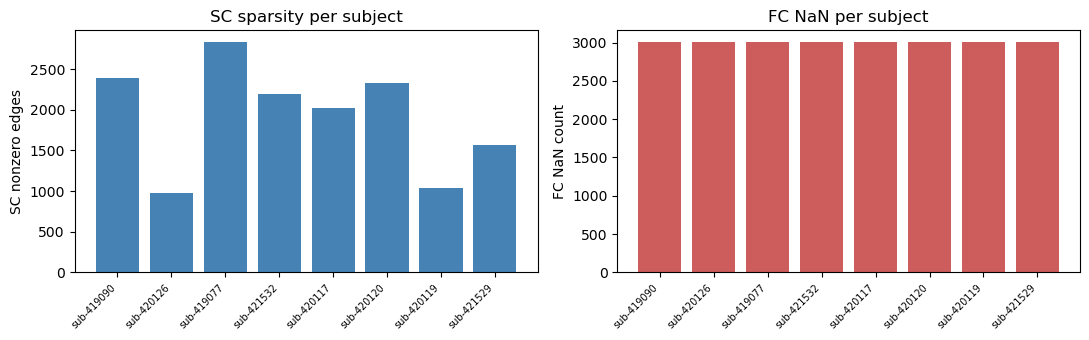

  saved: ./output_mouse_mptp/step1_subjects.png


In [3]:
df, fc_mat, sc_mat, fc_ids, sc_ids, bold_mat, bold_ids = (
    data_loader.load_raw_data()
)
subjects = data_loader.get_target_subjects(df, fc_ids, sc_ids)
train, val, test = data_loader.three_way_split(subjects)

subject_data = data_loader.load_all_subjects(
    train + val + test,
    fc_mat, sc_mat, fc_ids, sc_ids,
    bold_mat, bold_ids,
)

# Result
evaluate.report_step1(train, val, test, subject_data)


## Train data: weights / tract lengths / empirical FC

Step 1 직후 실행. Train subject 4명의 SC(weights), SC tract length, empirical FC를 로드하고 출력합니다.

  sub-419090:  SC=[0.1064, 1.0000]  length=[1.0, 15.6]mm  delay=[0.65, 10.38]ms  FC=[-0.658, 0.879]  SC_nnz=2388
  sub-420126:  SC=[0.1023, 1.0000]  length=[1.0, 10.8]mm  delay=[0.65, 7.20]ms  FC=[-0.770, 0.918]  SC_nnz=982
  sub-419077:  SC=[0.1008, 1.0000]  length=[1.0, 20.8]mm  delay=[0.65, 13.88]ms  FC=[-0.824, 0.936]  SC_nnz=2836
  sub-421532:  SC=[0.1107, 1.0000]  length=[1.0, 14.6]mm  delay=[0.65, 9.74]ms  FC=[-0.457, 0.885]  SC_nnz=2190
  sub-420117:  SC=[0.1028, 1.0000]  length=[1.0, 10.2]mm  delay=[0.65, 6.82]ms  FC=[-0.754, 0.859]  SC_nnz=2026
  sub-420120:  SC=[0.1033, 1.0000]  length=[1.0, 15.0]mm  delay=[0.65, 10.02]ms  FC=[-0.678, 0.961]  SC_nnz=2326


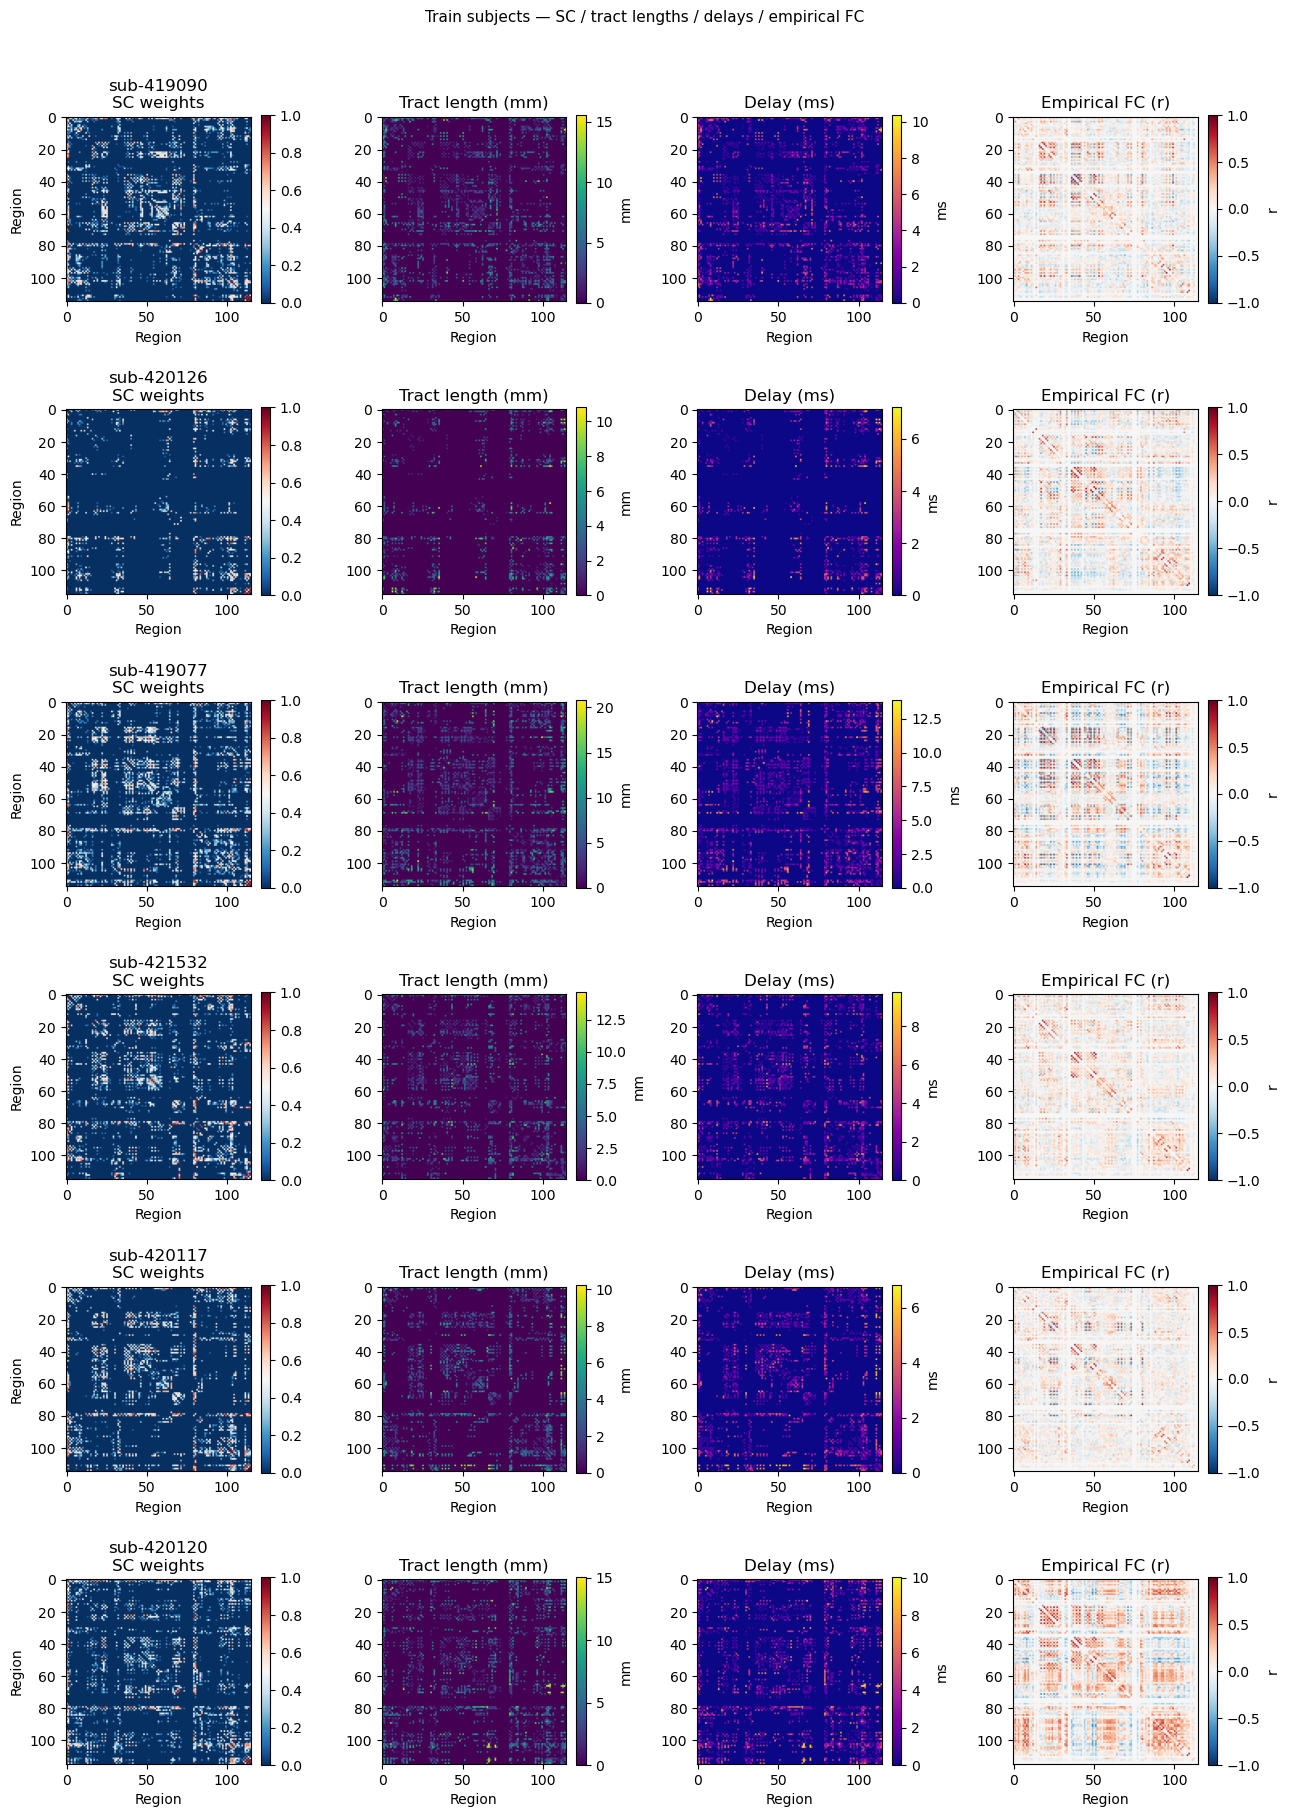

  saved: ./output_mouse_mptp/train_data_matrices.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

for sid in train:
    d  = subject_data[sid]
    w  = d["sc"].astype(np.float32)
    lm = d["lengths_mm"].astype(np.float32)
    dl = d["delays"].astype(np.float32)
    fc = d["fc"].astype(np.float32)

    w_pos  = w[w > 0]
    lm_pos = lm[lm > 0]
    dl_pos = dl[dl > 0]
    fc_off = fc[np.eye(fc.shape[0]) == 0]

    print(
        f"  {sid}:"
        f"  SC=[{w_pos.min():.4f}, {w_pos.max():.4f}]"
        f"  length=[{lm_pos.min():.1f}, {lm_pos.max():.1f}]mm"
        f"  delay=[{dl_pos.min():.2f}, {dl_pos.max():.2f}]ms"
        f"  FC=[{fc_off.min():.3f}, {fc_off.max():.3f}]"
        f"  SC_nnz={int((w > 0).sum())}"
    )

n_train = len(train)
fig, axes = plt.subplots(n_train, 4,
                         figsize=(13, 3.0 * n_train),
                         squeeze=False)

for row, sid in enumerate(train):
    d  = subject_data[sid]
    w  = d["sc"].astype(np.float32)
    lm = d["lengths_mm"].astype(np.float32)
    dl = d["delays"].astype(np.float32)
    fc = d["fc"].astype(np.float32)

    im0 = axes[row, 0].imshow(w, cmap="RdBu_r", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{sid}\nSC weights")
    axes[row, 0].set_ylabel("Region")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(lm, cmap="viridis")
    axes[row, 1].set_title("Tract length (mm)")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, label="mm")

    im2 = axes[row, 2].imshow(dl, cmap="plasma")
    axes[row, 2].set_title("Delay (ms)")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, label="ms")

    im3 = axes[row, 3].imshow(fc, cmap="RdBu_r", vmin=-1, vmax=1)
    axes[row, 3].set_title("Empirical FC (r)")
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046, label="r")

for ax in axes.flat:
    ax.set_xlabel("Region")

plt.suptitle(
    "Train subjects — SC / tract lengths / delays / empirical FC",
    fontsize=11, y=1.01,
)
plt.tight_layout()
save_path = "./output_mouse_mptp/train_data_matrices.png"
plt.savefig(save_path, dpi=110, bbox_inches="tight")
plt.show()
print(f"  saved: {save_path}")

## Step 7. Parameter preprocessing ([-1, 1] scaling)

Step 7 runs before step 2 because the simulation needs `prior_scaled` to sample parameters.

In [5]:
param_scaler, prior_scaled = inference.step7_fit_param_scaler(
    verbose=True
)

# Result
evaluate.report_step7(param_scaler)



  [Step 7] Parameter scaling ([-1, 1])
    P      : [0.5, 2.5] -> [-1, 1]
    Q      : [0.0, 2.0] -> [-1, 1]
    g_e    : [0.0, 1.5] -> [-1, 1]
    g_i    : [0.0, 1.5] -> [-1, 1]

  Step 7 result
  Prior bounds:
    P      : [  0.500,   2.500]  -> [-1, 1]
    Q      : [  0.000,   2.000]  -> [-1, 1]
    g_e    : [  0.000,   1.500]  -> [-1, 1]
    g_i    : [  0.000,   1.500]  -> [-1, 1]


## Step 2. WC simulation

Feature extraction (step 3) is interleaved inside this loop.

In [ ]:
import os

diag_bold = None
diag_sid = None

_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")
if os.path.exists(_feat_path):
    print(f"  [Step 2 skip] loading saved features: {_feat_path}")
    _loaded = inference.load_extracted_features(
        save_dir=config.OUTPUT_DIR, tag="stage1"
    )
    theta_scaled = _loaded["theta_scaled"]
    theta_raw    = _loaded["theta_raw"]
    fc_raw       = _loaded["fc_raw"]
    fcd_raw      = _loaded["fcd_raw"]
else:
    _result = inference.step2_simulate_train(
        train, subject_data, prior_scaled, param_scaler,
        n_sim=config.N_SIM, apply_bw=True, verbose=True,
        save_first_sample=True,
    )
    theta_scaled = _result["theta_scaled"]
    theta_raw    = _result["theta_raw"]
    fc_raw       = _result["fc_raw"]
    fcd_raw      = _result["fcd_raw"]
    diag_bold    = _result.get("diag_bold")
    diag_sid     = _result.get("diag_sid")

evaluate.report_step2(theta_scaled, fc_raw, fcd_raw)

  [19:01:51] [Step 2] WC simulation  N_SIM=50000  subjects=6
    config: GPU_BATCH=50000  T_end=300000ms  T_cut=60000ms  dt=0.5ms
            n_steps=600000  T_bold=240  N=115
            params: P, Q, g_e, g_i
  Training data collection: 6 subjects x 50000 = 300000 sims

[Step 2] Subject 1/6  sub-419090  N_SIM=50,000  GPU_BATCH=50,000
         sc_sparsity=0.181  delay_max=10.4ms  n_chunks=1

[Step 2] sub-419090  N_SIM=50,000  GPU_BATCH=50,000  n_chunks=1
  sub-419090   |░░░░░░░░░░░░░░░░░░░░| ~   510/50,000 |  1.0% |  5.9 sim/s | elapsed 01:26 | ETA 139:46   

### Step 2 진단: train subject 1명의 시뮬 결과 시각화

feature extraction 루프에서 캐싱한 첫 번째 시뮬 BOLD/FC를 재시뮬 없이 그대로 그립니다.

In [ ]:
if diag_bold is not None:
    _one_sim = evaluate.plot_one_simulation(
        sid=diag_sid,
        subject_data=subject_data,
        bold=diag_bold,
        sim_idx=0,
    )
else:
    print("  [Step 2 진단] diag_bold 없음 (캐시 로드 경로 또는 시뮬 실패) — 진단 출력 스킵")

## Step 3. Feature extraction summary

Step 2의 streaming loop 안에서 이미 추출된 feature를 정리하고, **raw feature를 디스크에 저장**합니다.

- `fc_raw` : FC upper triangle (Fisher z-transformed)
- `fcd_raw` : FCD upper triangle (element-wise std of sliding-window FCs)

저장 경로: `{OUTPUT_DIR}/features_stage1.npz`  
Load 방법: `inference.load_extracted_features(tag="stage1")`

In [ ]:
import os
inference.step3_summary_features(fc_raw, fcd_raw, verbose=True)

_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")
if not os.path.exists(_feat_path):
    inference.save_extracted_features(
        theta_scaled, theta_raw, fc_raw, fcd_raw,
        param_names=config.STAGE1_PARAMS,
        save_dir=config.OUTPUT_DIR,
        tag="stage1",
        verbose=True,
    )
else:
    print(f"  features_stage1.npz exists — skip save")

evaluate.report_step3(fc_raw, fcd_raw)


## Step 4. Feature preprocessing (z-score, train only)

In [ ]:
scalers = inference.step4_fit_feature_scalers(
    fc_raw, fcd_raw, verbose=True
)

# Result
evaluate.report_step4(scalers, fc_raw, fcd_raw)


## Step 5. Feature embedding (FC PCA + FCD summary stats)

- FC (6555-dim) → z-score → PCA → `PCA_DIM_FC` (default 200)
- FCD (5-dim summary stats: mean, std, q25, q50, q75) → z-score only
- Concatenated input dim = `PCA_DIM_FC + 5`

In [ ]:
pipeline, x_input = inference.step5_fit_feature_pipeline(
    fc_raw, fcd_raw, verbose=True
)

# Result
evaluate.report_step5(pipeline, x_input)


## Step 6. Embedding quality check (PCA diagnostic)

FC PCA의 explained variance, reconstruction quality, train/val drift를 확인합니다. FCD는 5-dim summary stats라 PCA 진단 없이 요약 정보만 출력합니다.

In [ ]:
pca_diagnostic = inference.step6_pca_diagnostic(
    pipeline, fc_raw, fcd_raw, verbose=True
)
evaluate.plot_pca_diagnostic(pca_diagnostic)

# Result
evaluate.report_step6(pca_diagnostic)


## Step 8. Stage 1 inference (single-round SNPE-C)

In [ ]:
posterior, embedding_net = inference.step8_train_snpe(
    theta_scaled, x_input, prior_scaled, verbose=True,
    fc_raw=fc_raw,
)

s1 = {
    "posterior":        posterior,
    "embedding_net":    embedding_net,
    "theta_scaled":     theta_scaled,
    "theta_raw":        theta_raw,
    "fc_raw":           fc_raw,
    "fcd_raw":          fcd_raw,
    "x_input":          x_input,
    "param_scaler":     param_scaler,
    "feature_pipeline": pipeline,
    "prior_scaled":     prior_scaled,
    "pca_diagnostic":   pca_diagnostic,
}

# Result
evaluate.report_step8(posterior, embedding_net, theta_scaled, x_input)

## Step 9. Stage 1 analysis (validation)

9a validation metrics · 9b baseline · 9c MLP probing · 9d SBC · 9e posterior plots

In [ ]:
s1_val_results, stage1_agg = evaluate.evaluate_validation_stage1(
    val, subject_data, s1, apply_bw=True, verbose=True,
)

baseline_agg = evaluate.baseline_eval_subjects(
    val, subject_data, n_resim=10, verbose=True,
)

inference.evaluate_embedding_probing(
    s1["embedding_net"], s1["theta_scaled"],
    s1["x_input"], config.STAGE1_PARAMS, verbose=True,
)

sbc_ranks = inference.simulation_based_calibration(
    s1["posterior"], s1["prior_scaled"], s1["param_scaler"],
    s1["feature_pipeline"], config.STAGE1_PARAMS,
    weights=subject_data[train[0]]["sc"],
    delays=subject_data[train[0]]["delays"],
    n_sbc=config.N_SBC, n_posterior=1000,
)
evaluate.plot_sbc_rank_histogram(sbc_ranks, config.STAGE1_PARAMS)
evaluate.plot_posteriors(
    stage1_agg["per_subject"],
    config.STAGE1_PARAMS,
    config.STAGE1_PRIOR_LOW,
    config.STAGE1_PRIOR_HIGH,
    title="Stage 1",
)

# Result
evaluate.report_step9(stage1_agg, baseline_agg)


## Step 10. Stage 2 parameter selection

In [ ]:
val_shrinkage = stage1_agg["shrinkage_mean"]
difficult = inference.select_difficult_params(val_shrinkage)

# Result
evaluate.report_step10(difficult, val_shrinkage)


## Step 11. Stage 2 inference

In [ ]:
import os

_feat_path_s2 = os.path.join(config.OUTPUT_DIR, "features_stage2.npz")
if os.path.exists(_feat_path_s2):
    print(f"  [Step 11 skip] loading saved features: {_feat_path_s2}")
    _loaded_s2 = inference.load_extracted_features(
        save_dir=config.OUTPUT_DIR, tag="stage2"
    )
    s2 = dict(s1)
    s2["theta_scaled"]  = _loaded_s2["theta_scaled"]
    s2["theta_raw"]     = _loaded_s2["theta_raw"]
    s2["fc_raw"]        = _loaded_s2["fc_raw"]
    s2["fcd_raw"]       = _loaded_s2["fcd_raw"]
    s2["stage2_params"] = _loaded_s2["param_names"]
else:
    s2 = inference.run_stage2_snpe(
        train, subject_data, s1, val_shrinkage,
        n_sim=config.N_SIM_S2, apply_bw=True, verbose=True,
    )
    inference.save_extracted_features(
        s2["theta_scaled"], s2["theta_raw"],
        s2["fc_raw"], s2["fcd_raw"],
        param_names=s2["stage2_params"],
        save_dir=config.OUTPUT_DIR,
        tag="stage2",
        verbose=True,
    )

evaluate.report_step11(s2)


## Step 12. Stage 2 analysis (validation)

In [ ]:
s2_val_results, stage2_agg = evaluate.evaluate_validation_stage2(
    val, subject_data, s2, s1, apply_bw=True, verbose=True,
)
evaluate.plot_posteriors(
    stage2_agg["per_subject"],
    s2["stage2_params"],
    s2["param_scaler"].low.tolist(),
    s2["param_scaler"].high.tolist(),
    title="Stage 2",
)

# Result
evaluate.report_step12(stage2_agg)


## Step 13. Model selection (validation)

In [ ]:
best_stage, scores = evaluate.select_best_model(
    stage1_agg, stage2_agg, baseline_agg, verbose=True,
)
score_1 = scores["stage1"]
score_2 = scores["stage2"]

# Result
evaluate.report_step13(best_stage, score_1, score_2, stage1_agg, stage2_agg)


## Step 14. Final test

In [ ]:
test_summary = evaluate.final_test(
    test, subject_data, best_stage, s1, s2,
    n_resim=config.N_TEST_RESIM, apply_bw=True, verbose=True,
)
evaluate.plot_fc_comparison(
    test_summary["per_subject"],
    save_path=os.path.join(config.OUTPUT_DIR, "test_fc_comparison.png"),
    title=f"Test FC (Stage {best_stage})",
)

# Result
evaluate.report_step14(test_summary)


## Save outputs and summary

In [ ]:
inference.save_artifacts(
    os.path.join(config.OUTPUT_DIR, "artifacts.pkl"),
    stage1_param_scaler     = s1["param_scaler"].to_dict(),
    stage1_feature_pipeline = s1["feature_pipeline"],
    stage1_pca_diagnostic   = s1["pca_diagnostic"],
    stage2_param_scaler     = s2["param_scaler"].to_dict() if s2 else None,
    stage2_feature_pipeline = s2["feature_pipeline"] if s2 else None,
    stage2_params           = s2["stage2_params"] if s2 else None,
    nuisance_params         = s2["nuisance_params"] if s2 else None,
    best_stage              = best_stage,
    n_regions               = config.N_REGIONS,
    fc_dim                  = config.FC_DIM,
    prior_low               = config.STAGE1_PRIOR_LOW,
    prior_high              = config.STAGE1_PRIOR_HIGH,
    param_names_s1          = config.STAGE1_PARAMS,
    c_param_prior           = config.C_PARAM_PRIOR,
    feature_config          = {
        "pca_dim_fc":  s1["feature_pipeline"].fc_pca.n_components,
        "pca_dim_fcd": s1["feature_pipeline"].fcd_pca.n_components,
    },
)

torch.save(
    s1["embedding_net"].state_dict(),
    os.path.join(config.OUTPUT_DIR, "embedding_net_s1.pt"),
)
if s2 is not None:
    torch.save(
        s2["embedding_net"].state_dict(),
        os.path.join(config.OUTPUT_DIR, "embedding_net_s2.pt"),
    )

evaluate.print_final_summary(
    stage1_agg, stage2_agg, best_stage, test_summary,
    train, len(s1["theta_scaled"]),
)
